# Tuần 4 — bản tổng hợp một trang

> **Đọc file này trước.** Bốn notebook `01`–`04` là bản đào sâu từng ý của mentor; file này gom
> toàn bộ kết quả thành một mạch, tự tính lại số từ dữ liệu chứ không chép sang.

## Kết luận trong một câu

**MAPE 14,65% không phải kết quả của một model chưa tối ưu — đó là mức nhiễu mà bộ dữ liệu bơm vào
từng báo giá.** Notebook này trình bày bằng chứng cho khẳng định đó, và hệ quả của nó lên kế hoạch
tuần tới.

| Mục | Câu hỏi | Trả lời ngắn |
|---|---|---|
| **1** | Sai số nằm ở tầng nào? | **98,9%** ở tầng giá cơ bản; hệ số nhân đã đạt MAPE 1,42% |
| **2** | Giá cơ bản còn dự đoán được nữa không? | Không — model **đã vượt trần thông tin** của dữ liệu |
| **3** | Yếu tố nào cấu thành giá? | Cung–cầu mạnh nhất **+35,1%**, và mọi yếu tố thị trường đi qua **hệ số nhân** |
| **4** | Model fail ở đâu? | Quãng đường (η² 0,0106), **không phải** thời điểm (η² ≈ 0) |
| **5** | Khoảng bất định thu hẹp được không? | Không — tốt nhất **−0,37%**; độ khó từng chuyến không dự đoán được |
| **6** | Model có hiểu cơ chế giá không? | Có — rút giá trễ ra, nó **tự bù 94%** hiệu ứng mưa |

> ⚠️ **Dữ liệu là synthetic** — toàn bộ 1,72 triệu chuyến có `is_synthetic = True`, một nền tảng,
> hai dịch vụ, ba khu vực. Mọi con số dưới đây mô tả **hành vi của bộ sinh dữ liệu**, không phải
> bằng chứng về thị trường TP.HCM thật.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from pathlib import Path
%matplotlib inline

BASE, MULT, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                       "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
DATA = Path("../data/hcm_train_ready.parquet")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC      = 0.90
CAO_DIEM = [(7, 9), (17, 19)]
CAT      = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
NHAN     = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
KMC      = [0, 2, 4, 6, 8, 10, 15, np.inf]
KMN      = ["<2", "2–4", "4–6", "6–8", "8–10", "10–15", ">15"]

# ── (a) tap du doan: dung cho sai so, khoang bat dinh, causality ──────────
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
uc = uc[uc.requested_lag_minutes == 5].copy()
t  = ut[ut.requested_lag_minutes == 5].copy()

for x in (uc, t):
    x["res"]  = (x.hybrid_pred - x.gia_that).abs() / x.hybrid_pred
    x["sai"]  = (x.hybrid_pred - x.gia_that).abs() / x.gia_that
    x["band"] = pd.cut(x.hybrid_pred, CAT, labels=NHAN)
    x["km"]   = pd.cut(x.quote_distance, KMC, labels=KMN)
    x["cao_diem"] = x.gio_vn.apply(lambda h: any(a <= h <= b for a, b in CAO_DIEM))
t["sai_ps"] = (t.persistence - t.gia_that).abs() / t.gia_that

print(f"Tập test  : {len(t):,} chuyến (độc lập theo thời gian)")
print(f"MAPE model: {t.sai.mean():.2%}   ·   persistence {t.sai_ps.mean():.2%}")

Tập test  : 216,090 chuyến (độc lập theo thời gian)
MAPE model: 14.65%   ·   persistence 27.84%


In [2]:
# ── (b) du lieu goc: dung cho phan tich cau thanh gia ────────────────────
COLS = ["target_request_id", "target_timestamp", "service_name",
        "pickup_location_name", "dropoff_location_name",
        "quote_distance", "quote_duration", "weather_main",
        "pricing_market_imbalance_5m_lag",
        "target_is_weekend", "target_shown_price", "target_shown_multiplier", "gio_vn"]
d = pd.read_parquet(DATA, columns=COLS).drop_duplicates("target_request_id")

d["gia"]  = d.target_shown_price
d["heso"] = d.target_shown_multiplier
d["base"] = d.gia / d.heso
d["cuoi_tuan"] = d.target_is_weekend.astype(bool)
d["cao_diem"]  = d.gio_vn.isin([7, 8, 9, 17, 18, 19])
d["premium"]   = d.service_name.str.contains("Premium")
d["mua"]       = d.weather_main == "Rain"
d["route"]     = d.pickup_location_name.astype(str) + "→" + d.dropoff_location_name.astype(str)
d["kmb"]       = (d.quote_distance // 1).astype(int)
d["kmh"]       = d.quote_distance / (d.quote_duration / 3600)  # km/h, duration tinh bang giay
d["cham"]      = d.groupby("kmb", observed=True).kmh.transform(lambda s: s < s.median())
d["ngay"]      = d.target_timestamp.dt.tz_convert("Asia/Ho_Chi_Minh").dt.date

print(f"Dữ liệu gốc: {len(d):,} chuyến độc lập · {d.ngay.nunique()} ngày")
print(f"Giá TB {d.gia.mean():,.0f}đ = giá cơ bản {d.base.mean():,.0f}đ × hệ số {d.heso.mean():.3f}")

Dữ liệu gốc: 1,724,714 chuyến độc lập · 90 ngày
Giá TB 121,367đ = giá cơ bản 103,642đ × hệ số 1.165


## 1–2. Sai số nằm ở tầng nào, và tầng đó còn cải thiện được không

Giá đối thủ có cấu trúc hai tầng — đúng cấu trúc mentor mô tả bằng cụm *market signal multiplier*:

$$\text{giá} = \text{giá cơ bản} \times \text{hệ số nhân}$$

Lấy log là tách được sai số theo tầng, vì $\log(\hat p/p) = \log(\hat b/b) + \log(\hat m/m)$.

In [3]:
t["lg_gia"]  = np.log(t.hybrid_pred / t.gia_that)
t["lg_base"] = np.log(t.base_pred   / t.base_that)
t["lg_heso"] = np.log(t.heso_pred   / t.heso_that)
print(f"Kiểm tra phép tách: sai lệch tối đa {(t.lg_gia - t.lg_base - t.lg_heso).abs().max():.1e}")

v_b, v_h, cov, tot = t.lg_base.var(), t.lg_heso.var(), t.lg_base.cov(t.lg_heso), t.lg_gia.var()
SHARE = {"Giá cơ bản": v_b/tot, "Hệ số nhân": v_h/tot, "Tương tác": 2*cov/tot}

MAPE_BASE = ((t.base_pred - t.base_that).abs() / t.base_that).mean()
MAPE_HESO = ((t.heso_pred - t.heso_that).abs() / t.heso_that).mean()
MAPE_GIA  = t.sai.mean()

# Oracle: cho MOT tang du doan hoan hao, giu nguyen tang kia
ORACLE = {
    "Hiện tại":            MAPE_GIA,
    "Giá cơ bản hoàn hảo": ((t.base_that*t.heso_pred - t.gia_that).abs() / t.gia_that).mean(),
    "Hệ số nhân hoàn hảo": ((t.base_pred*t.heso_that - t.gia_that).abs() / t.gia_that).mean(),
}
for k, v in SHARE.items():
    print(f"  phương sai · {k:12} {v:6.1%}")
print(f"\nMAPE riêng tầng: giá cơ bản {MAPE_BASE:.2%} · hệ số nhân {MAPE_HESO:.2%}")
for k, v in ORACLE.items():
    print(f"  oracle · {k:22} MAPE {v:.2%}  (giảm {1-v/MAPE_GIA:.0%})")

Kiểm tra phép tách: sai lệch tối đa 5.8e-08
  phương sai · Giá cơ bản    98.9%
  phương sai · Hệ số nhân     1.1%
  phương sai · Tương tác     -0.0%

MAPE riêng tầng: giá cơ bản 14.58% · hệ số nhân 1.42%
  oracle · Hiện tại               MAPE 14.65%  (giảm 0%)
  oracle · Giá cơ bản hoàn hảo    MAPE 1.42%  (giảm 90%)
  oracle · Hệ số nhân hoàn hảo    MAPE 14.58%  (giảm 0%)


In [4]:
# Tran thong tin cua GIA CO BAN: gom chuyen giong het nhau, lay trung binh o
d["km05"] = (d.quote_distance // 0.5).astype(int)
d["ph5"]  = (d.quote_duration // 300).astype(int)   # quote_duration tinh bang GIAY -> o 5 phut

def tran(khoa):
    tb = d.groupby(khoa, observed=True).base.transform("mean")
    n  = d.groupby(khoa, observed=True).base.transform("size")
    ok = n >= 30
    return ((tb[ok] - d.base[ok]).abs() / d.base[ok]).mean()

TRAN = {"Quãng đường":  tran(["km05"]),
        "+ thời lượng": tran(["km05", "ph5"]),
        "+ tuyến":      tran(["km05", "ph5", "route"]),
        "+ dịch vụ":    tran(["km05", "ph5", "route", "service_name"])}
for k, v in TRAN.items():
    print(f"  trần khi biết {k:14} MAPE {v:.2%}")
print(f"\n  ◆ model giá cơ bản hiện tại   MAPE {MAPE_BASE:.2%}  ← đã VƯỢT trần")

  trần khi biết Quãng đường    MAPE 16.74%
  trần khi biết + thời lượng   MAPE 15.22%
  trần khi biết + tuyến        MAPE 15.19%
  trần khi biết + dịch vụ      MAPE 14.98%

  ◆ model giá cơ bản hiện tại   MAPE 14.58%  ← đã VƯỢT trần


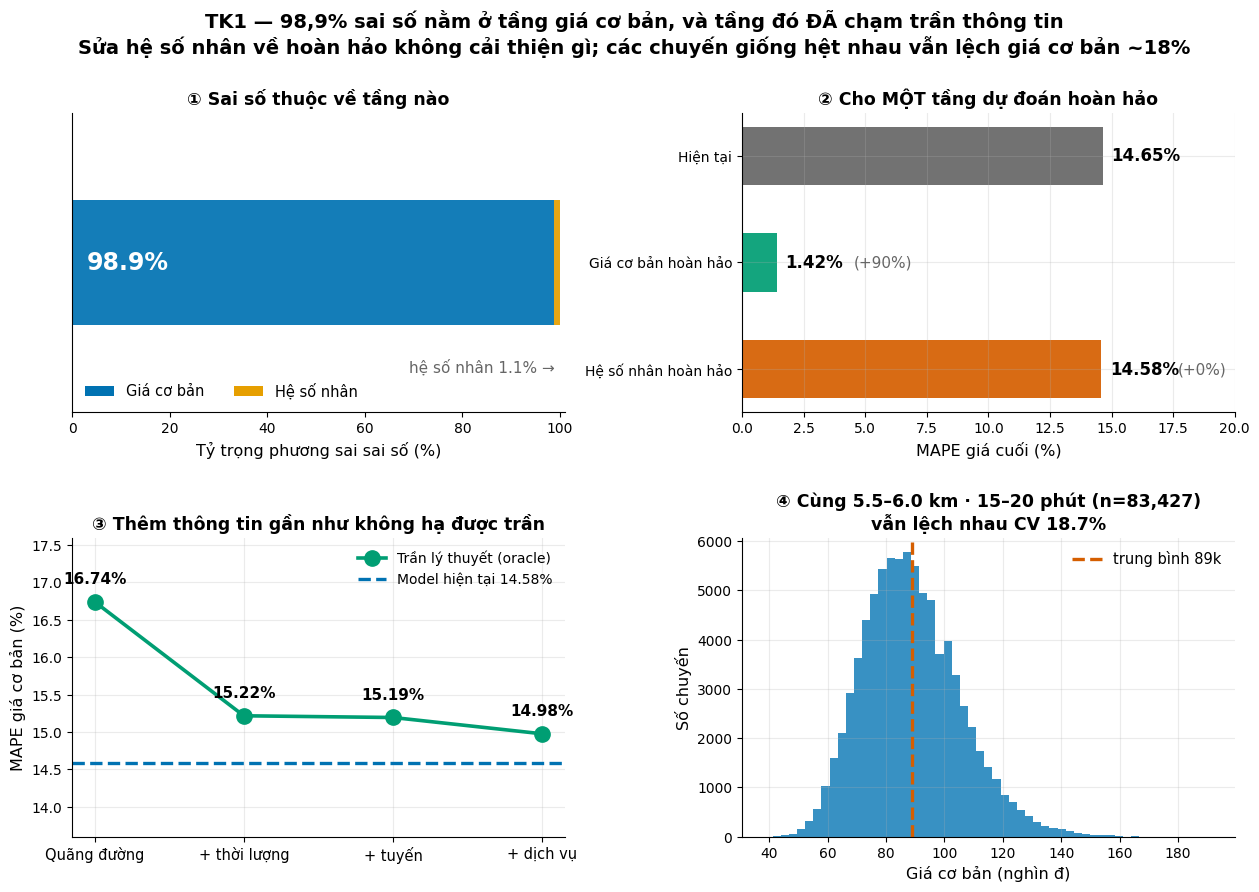

In [5]:
# ═════════ HINH TK1 — sai so nam o dau va con cai thien duoc khong ═════════
fig, ax = plt.subplots(2, 2, figsize=(15, 9.4))
fig.subplots_adjust(hspace=.42, wspace=.36)

# ① ty trong phuong sai
a = ax[0, 0]
x0 = 0
for ten, v, mau in [("Giá cơ bản", SHARE["Giá cơ bản"], BASE),
                    ("Hệ số nhân", SHARE["Hệ số nhân"], MULT)]:
    a.barh([0], [v*100], left=x0, color=mau, alpha=.92, height=.5)
    x0 += v*100
a.text(3, 0, f"{SHARE['Giá cơ bản']:.1%}", va="center", color="white",
       fontweight="bold", fontsize=17)
a.text(99, -.42, f"hệ số nhân {SHARE['Hệ số nhân']:.1%} →", ha="right", va="center",
       fontsize=11, color=MUT)
a.set_xlim(0, 101); a.set_ylim(-.6, .6); a.set_yticks([]); a.grid(False)
a.set_xlabel("Tỷ trọng phương sai sai số (%)")
a.set_title("① Sai số thuộc về tầng nào", fontweight="bold")
a.legend(handles=[Patch(facecolor=BASE, label="Giá cơ bản"),
                  Patch(facecolor=MULT, label="Hệ số nhân")],
         frameon=False, loc="lower left", ncol=2)

# ② oracle
a = ax[0, 1]
ten = list(ORACLE); val = [v*100 for v in ORACLE.values()]
mau = [MUT, GREEN, RED]
a.barh(range(3), val, color=mau, alpha=.92, height=.55)
for i, v in enumerate(val):
    a.text(v + .35, i, f"{v:.2f}%", va="center", fontweight="bold", fontsize=12)
    if i:
        a.text(v + 3.1, i, f"({1-val[i]/val[0]:+.0%})", va="center", fontsize=11, color=MUT)
a.set_yticks(range(3)); a.set_yticklabels(ten); a.invert_yaxis()
a.set_xlim(0, 20); a.set_xlabel("MAPE giá cuối (%)")
a.set_title("② Cho MỘT tầng dự đoán hoàn hảo", fontweight="bold")

# ③ tran thong tin
a = ax[1, 0]
xs = range(len(TRAN))
a.plot(xs, [v*100 for v in TRAN.values()], "o-", color=GREEN, lw=2.6, ms=11,
       label="Trần lý thuyết (oracle)")
for i, v in enumerate(TRAN.values()):
    a.annotate(f"{v:.2%}", (i, v*100), textcoords="offset points", xytext=(0, 13),
               ha="center", fontweight="bold", fontsize=11)
a.axhline(MAPE_BASE*100, color=BASE, lw=2.4, ls="--",
          label=f"Model hiện tại {MAPE_BASE:.2%}")
a.set_xticks(list(xs)); a.set_xticklabels(list(TRAN), fontsize=10.5)
a.set_ylim(13.6, 17.6); a.set_ylabel("MAPE giá cơ bản (%)")
a.set_title("③ Thêm thông tin gần như không hạ được trần", fontweight="bold")
a.legend(frameon=False, loc="upper right", fontsize=10)

# ④ phan bo base trong mot o giong het nhau
a = ax[1, 1]
o = d.groupby(["km05", "ph5"]).size().idxmax()
sub = d[(d.km05 == o[0]) & (d.ph5 == o[1])]
a.hist(sub.base/1000, bins=55, color=BASE, alpha=.78)
a.axvline(sub.base.mean()/1000, color=RED, lw=2.4, ls="--",
          label=f"trung bình {sub.base.mean()/1000:.0f}k")
a.set_xlabel("Giá cơ bản (nghìn đ)"); a.set_ylabel("Số chuyến")
a.set_title(f"④ Cùng {o[0]*.5:.1f}–{o[0]*.5+.5:.1f} km · {o[1]*5}–{o[1]*5+5} phút "
            f"(n={len(sub):,})\nvẫn lệch nhau CV {sub.base.std()/sub.base.mean():.1%}",
            fontweight="bold")
a.legend(frameon=False)

fig.suptitle("TK1 — 98,9% sai số nằm ở tầng giá cơ bản, và tầng đó ĐÃ chạm trần thông tin\n"
             "Sửa hệ số nhân về hoàn hảo không cải thiện gì; các chuyến giống hệt nhau "
             "vẫn lệch giá cơ bản ~18%",
             fontweight="bold", fontsize=14, y=.99)
fig.savefig(HINH / "TK1_sai_so_o_tang_nao.png")
plt.show()

**Đọc hình TK1:**

- ① **98,9%** phương sai sai số thuộc tầng giá cơ bản. Tầng hệ số nhân chỉ 1,1%.
- ② Cho giá cơ bản dự đoán hoàn hảo → MAPE giá cuối rơi xuống **1,42%** (−90%). Cho hệ số nhân
  hoàn hảo → **14,58%**, tức **giảm 0%**.
- ③ Trần lý thuyết khi biết quãng đường + thời lượng + tuyến + dịch vụ là **14,98%**. Model đạt
  **14,58%** — đã vượt trần (nhờ dùng thêm giá cơ bản quan sát trễ). Thêm *tuyến* chỉ hạ trần
  **0,03 điểm**.
- ④ Các chuyến giống hệt nhau về km và thời lượng vẫn có giá cơ bản trải rộng **CV ~18%**. Đó là
  nhiễu bơm vào từng báo giá — không có quy luật để học.

> Trần ở ③ còn được ước lượng **lạc quan** vì trung bình ô tính in-sample. Trần thật cao hơn, nên
> kết luận càng chắc.

## 3. Yếu tố nào cấu thành một mức giá

Ceteris paribus bằng **đối chứng ghép cặp**: chia thành các ô giống nhau ở mọi yếu tố khống chế,
so hai nhóm trong từng ô, bình quân theo số chuyến. Cùng một phép đo chạy trên `gia`, `base`,
`heso` — nên ba con số so sánh trực tiếp được.

In [6]:
def ghep_cap(yeu_to, khong_che):
    out = {}
    for cot in ["gia", "base", "heso"]:
        g = (d.groupby(khong_che + [yeu_to], observed=True)[cot]
               .agg(["mean", "size"]).unstack(yeu_to).dropna())
        n = g[("size", False)] + g[("size", True)]
        w = n / n.sum()
        out[cot] = float(((g[("mean", True)] / g[("mean", False)] - 1) * w).sum())
    return out

YEU_TO = [("Đường tắc (cùng km)", "cham",      ["kmb", "gio_vn", "weather_main"]),
          ("Giờ cao điểm",        "cao_diem",  ["kmb", "weather_main", "cuoi_tuan"]),
          ("Trời mưa",            "mua",       ["kmb", "gio_vn", "cuoi_tuan"]),
          ("Cuối tuần",           "cuoi_tuan", ["kmb", "gio_vn", "weather_main"]),
          ("Dịch vụ Premium",     "premium",   ["kmb", "gio_vn", "weather_main"])]

hang = [dict(Yếu_tố=ten, **ghep_cap(yt, kc)) for ten, yt, kc in YEU_TO]

# Cung-cau: bien lien tuc -> chia ngu phan vi, so nhom cao nhat voi nhom thap nhat
d["mi_q"] = pd.qcut(d.pricing_market_imbalance_5m_lag, 5, labels=["Q1","Q2","Q3","Q4","Q5"])
KC = ["kmb", "gio_vn", "weather_main"]
g = d.groupby(KC + ["mi_q"], observed=True)[["gia","base","heso"]].mean().unstack("mi_q").dropna()
n = d.groupby(KC + ["mi_q"], observed=True).size().unstack("mi_q").dropna().sum(axis=1)
w = n / n.sum()
CC = {c: [float(((g[(c,q)]/g[(c,"Q1")] - 1)*w).sum()) for q in ["Q1","Q2","Q3","Q4","Q5"]]
      for c in ["gia","base","heso"]}
hang.insert(0, {"Yếu_tố": "Cung–cầu (Q1→Q5)", **{c: CC[c][-1] for c in CC}})

yt = pd.DataFrame(hang).sort_values("gia", ascending=False).reset_index(drop=True)
yt["qua_heso"] = yt.heso / yt.gia
yt.columns = ["Yếu tố", "Giá cuối", "Giá cơ bản", "Hệ số nhân", "Phần qua hệ số nhân"]
yt.style.format({"Giá cuối": "{:+.2%}", "Giá cơ bản": "{:+.2%}", "Hệ số nhân": "{:+.2%}",
                 "Phần qua hệ số nhân": "{:.0%}"}).hide(axis="index")

Yếu tố,Giá cuối,Giá cơ bản,Hệ số nhân,Phần qua hệ số nhân
Cung–cầu (Q1→Q5),+35.08%,+5.60%,+27.90%,80%
Đường tắc (cùng km),+16.52%,+13.43%,+2.70%,16%
Giờ cao điểm,+11.86%,+0.80%,+11.07%,93%
Trời mưa,+9.72%,+3.24%,+6.25%,64%
Cuối tuần,+6.26%,+0.13%,+6.14%,98%
Dịch vụ Premium,-1.29%,-1.02%,-0.25%,20%


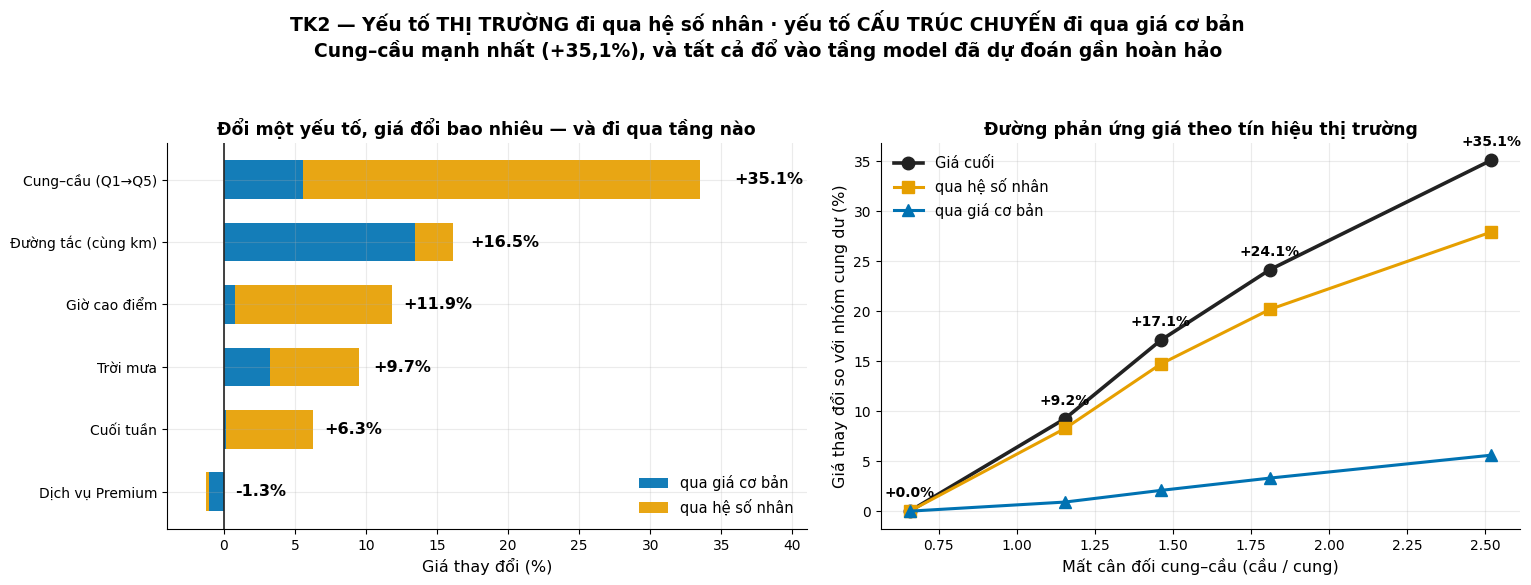

In [7]:
# ═════════ HINH TK2 — cau thanh gia ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5.6))

a = ax[0]
p = yt.iloc[::-1].reset_index(drop=True)
y = np.arange(len(p))
a.barh(y, p["Giá cơ bản"]*100, color=BASE, alpha=.92, height=.62, label="qua giá cơ bản")
a.barh(y, p["Hệ số nhân"]*100, left=p["Giá cơ bản"]*100, color=MULT, alpha=.92,
       height=.62, label="qua hệ số nhân")
for i in y:
    v = p["Giá cuối"].iloc[i]
    a.text(max(v*100, 0) + .8, i, f"{v:+.1%}", va="center", fontweight="bold", fontsize=11.5)
a.axvline(0, color=INK, lw=1.2)
a.set_yticks(y); a.set_yticklabels(p["Yếu tố"])
a.set_xlim(-4, 41); a.set_xlabel("Giá thay đổi (%)")
a.set_title("Đổi một yếu tố, giá đổi bao nhiêu — và đi qua tầng nào", fontweight="bold")
a.legend(frameon=False, loc="lower right")

a = ax[1]
mi = d.groupby("mi_q", observed=True).pricing_market_imbalance_5m_lag.mean().values
a.plot(mi, np.array(CC["gia"])*100,  "o-", color=INK,  lw=2.6, ms=9, label="Giá cuối")
a.plot(mi, np.array(CC["heso"])*100, "s-", color=MULT, lw=2.2, ms=8, label="qua hệ số nhân")
a.plot(mi, np.array(CC["base"])*100, "^-", color=BASE, lw=2.2, ms=8, label="qua giá cơ bản")
for i, v in enumerate(CC["gia"]):
    a.annotate(f"{v:+.1%}", (mi[i], v*100), textcoords="offset points", xytext=(0, 10),
               ha="center", fontsize=10, fontweight="bold")
a.set_xlabel("Mất cân đối cung–cầu (cầu / cung)")
a.set_ylabel("Giá thay đổi so với nhóm cung dư (%)")
a.set_title("Đường phản ứng giá theo tín hiệu thị trường", fontweight="bold")
a.legend(frameon=False, loc="upper left")

fig.suptitle("TK2 — Yếu tố THỊ TRƯỜNG đi qua hệ số nhân · yếu tố CẤU TRÚC CHUYẾN đi qua giá cơ bản\n"
             "Cung–cầu mạnh nhất (+35,1%), và tất cả đổ vào tầng model đã dự đoán gần hoàn hảo",
             fontweight="bold", fontsize=13.5, y=1.04)
fig.tight_layout()
fig.savefig(HINH / "TK2_cau_thanh_gia.png")
plt.show()

In [8]:
# Ngay le: ky du lieu co chua Tet Nguyen Dan 17/02/2026
nd = d.groupby("ngay").agg(gia=("gia","mean"), base=("base","mean"), heso=("heso","mean"))
TET = pd.Timestamp("2026-02-17").date()
hang_tet = int((nd.gia > nd.gia.loc[TET]).sum()) + 1
print(f"Giá TB toàn kỳ : {nd.gia.mean():,.0f}đ  (độ lệch chuẩn theo ngày {nd.gia.std():,.0f}đ)")
print(f"Giá ngày Tết   : {nd.gia.loc[TET]:,.0f}đ  →  xếp thứ {hang_tet}/{len(nd)} (1 = đắt nhất)")
print("\n⇒ Bộ sinh dữ liệu KHÔNG mô hình hoá ngày lễ. Thêm cột public_holiday vào bộ này")
print("  sẽ tạo ra một feature rỗng tín hiệu.")

Giá TB toàn kỳ : 121,178đ  (độ lệch chuẩn theo ngày 4,709đ)
Giá ngày Tết   : 116,173đ  →  xếp thứ 81/90 (1 = đắt nhất)

⇒ Bộ sinh dữ liệu KHÔNG mô hình hoá ngày lễ. Thêm cột public_holiday vào bộ này
  sẽ tạo ra một feature rỗng tín hiệu.


**Quy luật xuyên suốt:** yếu tố **thị trường** (cung–cầu, giờ cao điểm, cuối tuần) đi qua **hệ số
nhân**; yếu tố **cấu trúc chuyến** (quãng đường, tắc đường) đi qua **giá cơ bản**.

**Trời mưa là ngoại lệ duy nhất** — nó đi cả hai đường: vừa tăng cầu (hệ số nhân), vừa làm đường
tắc khiến chuyến lâu hơn (giá cơ bản). Chuỗi nhân quả khép kín.

**Ngày lễ:** mentor nêu đích danh, nhưng bộ dữ liệu không có — cả cột lẫn hiện tượng.

## 4–5. Model fail ở đâu, và khoảng bất định thu hẹp được không

In [9]:
def eta2(c):
    tong = ((t.sai - t.sai.mean())**2).sum()
    gr = t.groupby(c, observed=True).sai
    return float((gr.count() * (gr.mean() - t.sai.mean())**2).sum() / tong)

t["mua"] = t.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
CHIEU = [("Quãng đường","km"), ("Band giá","band"), ("Giờ trong ngày","gio_vn"),
         ("Thời tiết","weather_main"), ("Giờ cao điểm","cao_diem"), ("Đang mưa","mua")]
xh = pd.DataFrame([{"Chiều": ten, "η²": eta2(c),
                    "MAPE thấp": t.groupby(c, observed=True).sai.mean().min(),
                    "MAPE cao":  t.groupby(c, observed=True).sai.mean().max()}
                   for ten, c in CHIEU]).sort_values("η²", ascending=False)
xh["Biên độ (điểm)"] = (xh["MAPE cao"] - xh["MAPE thấp"]) * 100
xh.style.format({"η²": "{:.4f}", "MAPE thấp": "{:.2%}", "MAPE cao": "{:.2%}",
                 "Biên độ (điểm)": "{:.2f}"}).background_gradient(
    cmap="Reds", subset=["η²"]).hide(axis="index")

Chiều,η²,MAPE thấp,MAPE cao,Biên độ (điểm)
Quãng đường,0.0106,9.16%,17.52%,8.37
Band giá,0.0015,13.46%,18.55%,5.08
Giờ trong ngày,0.0001,14.48%,14.85%,0.37
Thời tiết,0.0000,14.56%,14.68%,0.13
Đang mưa,0.0000,14.62%,14.68%,0.06
Giờ cao điểm,0.0000,14.61%,14.66%,0.05


In [10]:
# Bon cach hieu chinh khoang, khong dung model
q_global = uc.res.quantile(MUC)
def danh_gia(q):
    q = pd.Series(np.asarray(q, dtype=float), index=t.index)
    trong = (t.gia_that >= t.hybrid_pred*(1-q)) & (t.gia_that <= t.hybrid_pred*(1+q))
    return q.mean(), trong.mean(), trong

hc = [("Conformal toàn cục", *danh_gia(q_global)[:2])]
COV = {}
for c, ten in [("band","band giá"), ("km","quãng đường"), ("gio_vn","giờ"),
               ("weather_main","thời tiết")]:
    qb = uc.groupby(c, observed=True).res.quantile(MUC)
    r, cv, tr = danh_gia(t[c].map(qb).astype(float).fillna(q_global))
    hc.append((f"Mondrian theo {ten}", r, cv))
    if c in ("band","km"): COV[c] = tr

hcb = pd.DataFrame(hc, columns=["Cách hiệu chỉnh", "Nửa độ rộng", "Coverage"])
hcb["Hẹp hơn gốc"] = hcb["Nửa độ rộng"]/hcb["Nửa độ rộng"].iloc[0] - 1

# Do lon sai so co du doan duoc khong -> tran cua moi cach hieu chinh
Xc = pd.DataFrame({"km": uc.quote_distance, "phut": uc.quote_duration,
                   "gio": uc.gio_vn, "pred": uc.hybrid_pred})
Xt = pd.DataFrame({"km": t.quote_distance, "phut": t.quote_duration,
                   "gio": t.gio_vn, "pred": t.hybrid_pred})
res_dd = HistGradientBoostingRegressor(max_iter=200, random_state=0).fit(Xc, uc.res).predict(Xt)
RHO = spearmanr(res_dd, t.res).statistic

print(f"Tương quan hạng giữa độ khó DỰ ĐOÁN được và sai số THẬT: {RHO:+.4f}")
print(f"Trần lý thuyết nếu biết trước độ khó: ±{t.res.mean():.2%} "
      f"(hiện tại ±{q_global:.2%}, tức {t.res.mean()/q_global-1:.0%})\n")
hcb.style.format({"Nửa độ rộng": "{:.2%}", "Coverage": "{:.2%}",
                  "Hẹp hơn gốc": "{:+.2%}"}).hide(axis="index")

Tương quan hạng giữa độ khó DỰ ĐOÁN được và sai số THẬT: +0.0530
Trần lý thuyết nếu biết trước độ khó: ±14.68% (hiện tại ±30.07%, tức -51%)



Cách hiệu chỉnh,Nửa độ rộng,Coverage,Hẹp hơn gốc
Conformal toàn cục,30.07%,89.81%,+0.00%
Mondrian theo band giá,30.11%,89.84%,+0.11%
Mondrian theo quãng đường,29.96%,89.77%,-0.37%
Mondrian theo giờ,30.07%,89.78%,-0.02%
Mondrian theo thời tiết,30.07%,89.80%,-0.01%


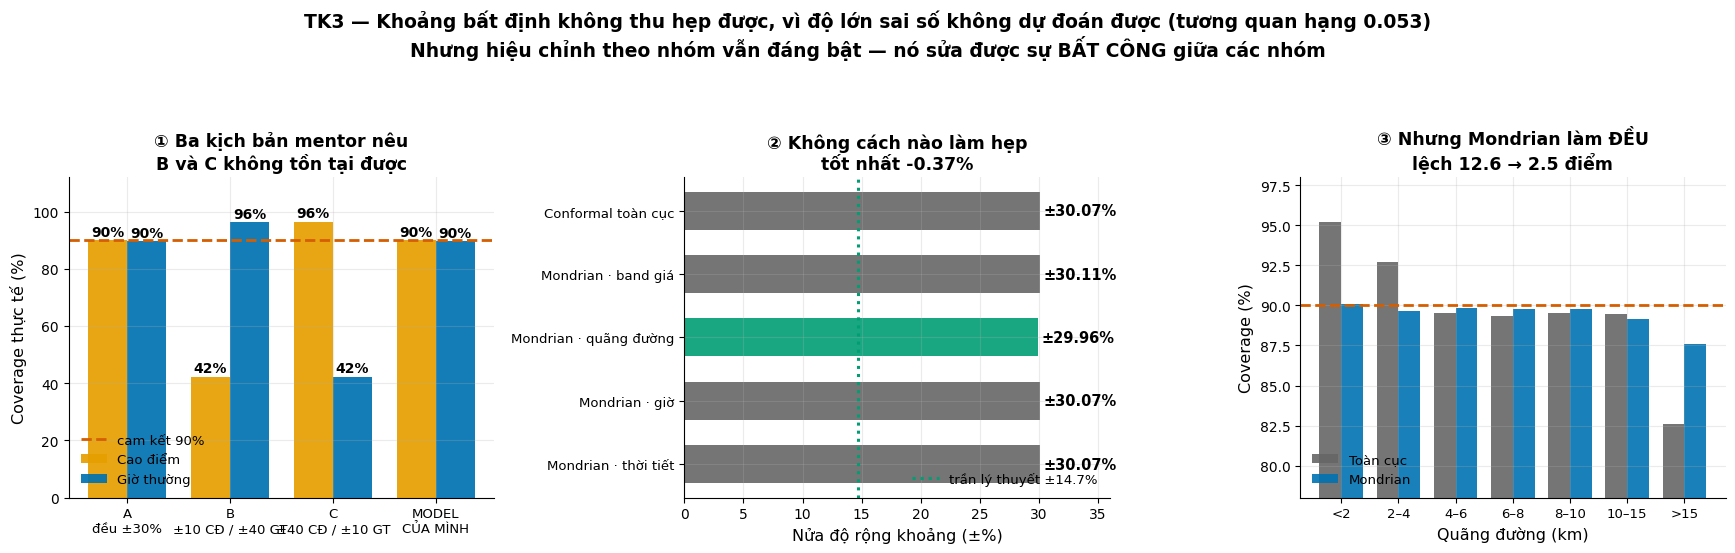

In [11]:
# ═════════ HINH TK3 — bat dinh: khong hep duoc, nhung lam DEU duoc ═════════
fig, ax = plt.subplots(1, 3, figsize=(17.5, 5.2))

# ① ba kich ban mentor neu
a = ax[0]
KB = [("A\nđều ±30%", .30, .30), ("B\n±10 CĐ / ±40 GT", .10, .40),
      ("C\n±40 CĐ / ±10 GT", .40, .10), ("MODEL\nCỦA MÌNH", None, None)]
q_mine = t.band.map(uc.groupby("band", observed=True).res.quantile(MUC)).astype(float)\
          .fillna(q_global)
cd = t.cao_diem
rows = []
for ten, qcd, qgt in KB:
    q = q_mine if qcd is None else pd.Series(np.where(cd, qcd, qgt), index=t.index)
    tr = (t.gia_that >= t.hybrid_pred*(1-q)) & (t.gia_that <= t.hybrid_pred*(1+q))
    rows.append((ten, tr[cd].mean(), tr[~cd].mean()))
x = np.arange(4); w = .38
a.bar(x - w/2, [r[1]*100 for r in rows], w, color=MULT, alpha=.92, label="Cao điểm")
a.bar(x + w/2, [r[2]*100 for r in rows], w, color=BASE, alpha=.92, label="Giờ thường")
a.axhline(MUC*100, color=RED, lw=2, ls="--", label="cam kết 90%")
for i, r in enumerate(rows):
    a.text(i - w/2, r[1]*100 + 1.5, f"{r[1]:.0%}", ha="center", fontweight="bold", fontsize=10)
    a.text(i + w/2, r[2]*100 + 1.5, f"{r[2]:.0%}", ha="center", fontweight="bold", fontsize=10)
a.set_xticks(x); a.set_xticklabels([r[0] for r in rows], fontsize=9.5)
a.set_ylim(0, 112); a.set_ylabel("Coverage thực tế (%)")
a.set_title("① Ba kịch bản mentor nêu\nB và C không tồn tại được", fontweight="bold")
a.legend(frameon=False, fontsize=9.5, ncol=1, loc="lower left")

# ② khong cach nao lam hep
a = ax[1]
y = np.arange(len(hcb))
a.barh(y, hcb["Nửa độ rộng"]*100, color=[GREEN if i == hcb["Nửa độ rộng"].idxmin() else MUT
                                          for i in y], alpha=.9, height=.6)
for i in y:
    a.text(hcb["Nửa độ rộng"].iloc[i]*100 + .3, i, f"±{hcb['Nửa độ rộng'].iloc[i]:.2%}",
           va="center", fontsize=10.5, fontweight="bold")
a.axvline(t.res.mean()*100, color=GREEN, lw=2.2, ls=":",
          label=f"trần lý thuyết ±{t.res.mean():.1%}")
a.set_yticks(y); a.set_yticklabels([s.replace("Mondrian theo ", "Mondrian · ")
                                    for s in hcb["Cách hiệu chỉnh"]], fontsize=9.5)
a.invert_yaxis(); a.set_xlim(0, 36); a.set_xlabel("Nửa độ rộng khoảng (±%)")
a.set_title(f"② Không cách nào làm hẹp\ntốt nhất {hcb['Hẹp hơn gốc'].min():+.2%}",
            fontweight="bold")
a.legend(frameon=False, fontsize=9.5, loc="lower right")

# ③ nhung Mondrian lam DEU
a = ax[2]
cg = COV["km"].groupby(t.km, observed=True).mean().reindex(KMN)
q0 = pd.Series(q_global, index=t.index)
tr0 = (t.gia_that >= t.hybrid_pred*(1-q0)) & (t.gia_that <= t.hybrid_pred*(1+q0))
c0 = tr0.groupby(t.km, observed=True).mean().reindex(KMN)
x = np.arange(len(KMN)); w = .38
a.bar(x - w/2, c0*100, w, color=MUT,  alpha=.9, label="Toàn cục")
a.bar(x + w/2, cg*100, w, color=BASE, alpha=.9, label="Mondrian")
a.axhline(MUC*100, color=RED, lw=2, ls="--")
a.set_xticks(x); a.set_xticklabels(KMN, fontsize=9.5)
a.set_ylim(78, 98); a.set_ylabel("Coverage (%)"); a.set_xlabel("Quãng đường (km)")
a.set_title(f"③ Nhưng Mondrian làm ĐỀU\nlệch {(c0.max()-c0.min())*100:.1f} → "
            f"{(cg.max()-cg.min())*100:.1f} điểm", fontweight="bold")
a.legend(frameon=False, fontsize=9.5, loc="lower left")

fig.suptitle("TK3 — Khoảng bất định không thu hẹp được, vì độ lớn sai số không dự đoán được "
             f"(tương quan hạng {RHO:.3f})\n"
             "Nhưng hiệu chỉnh theo nhóm vẫn đáng bật — nó sửa được sự BẤT CÔNG giữa các nhóm",
             fontweight="bold", fontsize=13.5, y=1.06)
fig.tight_layout()
fig.savefig(HINH / "TK3_khoang_bat_dinh.png")
plt.show()

**Đọc hình TK3:**

- ① Con số **±30%** mentor đưa ra trúng phóc — chạy thật cho coverage 89,7%. Model mình là **kịch
  bản A**. Kịch bản B và C **không tồn tại được**: khung được cấp ±10% chỉ giữ 42,3% coverage.
- ② Không cách hiệu chỉnh nào làm khoảng hẹp hơn (tốt nhất **−0,37%**). Trần lý thuyết là ±14,7%
  nhưng không với tới được — độ khó từng chuyến không dự đoán được.
- ③ **Nhưng Mondrian vẫn đáng bật:** nhóm `>15 km` — chuyến đắt tiền nhất — đang bị hụt gần 8 điểm
  coverage dưới hiệu chỉnh toàn cục. Chi phí vài giờ, không train lại.

## 6. Model có hiểu cơ chế giá không

Model có feature **giá đối thủ quan sát ở thời điểm trễ**. Khi trời mưa, giá thị trường đã tăng
*trước khi* model được hỏi — nên nó chỉ cần chép là ra đáp án đúng, không cần hiểu gì về mưa.

Phép thử: `persistence` là **đúng cái giá trễ đó dùng thẳng làm dự đoán**, hoàn toàn mù thời tiết.
Dữ liệu có bốn độ trễ — độ trễ càng lớn, cái nạng càng yếu.

In [12]:
def hieu_ung_mua(df):
    df = df.copy()
    df["mua"] = df.weather_main == "Rain"
    df["kmb"] = pd.cut(df.quote_distance, np.arange(0, 22, 1))
    out = {}
    for nhan, cot in [("that","gia_that"), ("model","hybrid_pred"), ("ps","persistence")]:
        g = (df.groupby(["kmb","gio_vn","mua"], observed=True)[cot]
               .agg(["mean","size"]).unstack("mua").dropna())
        n = g[("size",False)] + g[("size",True)]; w = n/n.sum()
        out[nhan] = float(((g[("mean",True)]/g[("mean",False)] - 1)*w).sum())
    return out

LAGS = sorted(ut.requested_lag_minutes.unique())
lg = pd.DataFrame([{"Độ trễ (phút)": int(l), **hieu_ung_mua(ut[ut.requested_lag_minutes == l])}
                   for l in LAGS])
lg["Khoảng trống"] = lg.that - lg.ps
lg["Model bù được"] = (lg.model - lg.ps) / lg["Khoảng trống"]
lg.columns = ["Độ trễ (phút)", "Thực tế", "Model", "Persistence", "Khoảng trống", "Model bù được"]
lg.style.format({"Thực tế": "{:+.2%}", "Model": "{:+.2%}", "Persistence": "{:+.2%}",
                 "Khoảng trống": "{:+.2%}", "Model bù được": "{:.0%}"}).hide(axis="index")

Độ trễ (phút),Thực tế,Model,Persistence,Khoảng trống,Model bù được
5,+10.30%,+10.34%,+8.99%,+1.32%,103%
10,+10.30%,+10.13%,+7.90%,+2.40%,93%
15,+10.30%,+10.10%,+7.14%,+3.17%,94%
30,+10.30%,+9.97%,+4.53%,+5.77%,94%


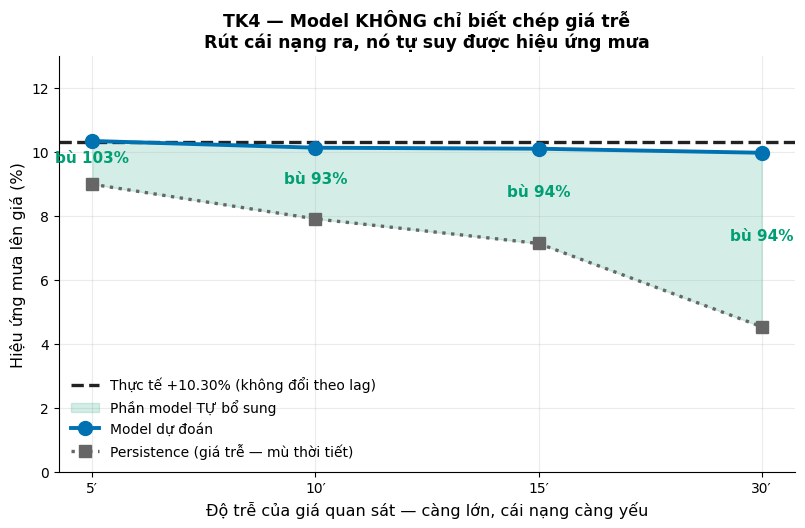

In [13]:
# ═════════ HINH TK4 — rut cai nang ra ═════════
fig, a = plt.subplots(figsize=(9.5, 5.4))
x = np.arange(len(LAGS))
a.axhline(lg["Thực tế"].iloc[0]*100, color=INK, lw=2.4, ls="--",
          label=f"Thực tế {lg['Thực tế'].iloc[0]:+.2%} (không đổi theo lag)")
a.fill_between(x, lg["Persistence"]*100, lg["Model"]*100, color=GREEN, alpha=.17,
               label="Phần model TỰ bổ sung")
a.plot(x, lg["Model"]*100, "o-", color=BASE, lw=2.8, ms=10, label="Model dự đoán")
a.plot(x, lg["Persistence"]*100, "s:", color=MUT, lw=2.4, ms=9,
       label="Persistence (giá trễ — mù thời tiết)")
for i in x:
    a.annotate(f"bù {lg['Model bù được'].iloc[i]:.0%}",
               (i, (lg["Model"].iloc[i] + lg["Persistence"].iloc[i])/2*100),
               ha="center", fontsize=11, fontweight="bold", color=GREEN)
a.set_xticks(x); a.set_xticklabels([f"{l}′" for l in LAGS])
a.set_xlabel("Độ trễ của giá quan sát — càng lớn, cái nạng càng yếu")
a.set_ylabel("Hiệu ứng mưa lên giá (%)"); a.set_ylim(0, 13)
a.set_title("TK4 — Model KHÔNG chỉ biết chép giá trễ\n"
            "Rút cái nạng ra, nó tự suy được hiệu ứng mưa", fontweight="bold")
a.legend(frameon=False, loc="lower left", fontsize=10)
fig.savefig(HINH / "TK4_rut_cai_nang.png")
plt.show()

Ở lag 30 phút, giá trễ chỉ còn giải thích **+4,53%** trong **+10,30%** thực tế — cái nạng gãy hơn
một nửa. Model vẫn ra **+9,97%**, tức **tự bù 94%** phần thiếu.

> **Model hiểu cơ chế, nhưng ưu tiên đường tắt khi đường tắt còn dùng được.** Đây là hành vi hợp lý
> của một model tối ưu MAE, không phải lỗi. Nó cũng sửa lại kết luận tuần 3 (*"model bám giá quan
> sát chứ không hiểu cơ chế"*) — phát biểu đó quá nặng.

## Kết luận — ba mảnh ghép lại

| # | Bằng chứng | Từ mục |
|---|---|---|
| **1** | **98,9%** phương sai sai số nằm ở tầng **giá cơ bản**; hệ số nhân đã đạt MAPE **1,42%** | 1–2 |
| **2** | **Mọi yếu tố thị trường** đi vào tầng **hệ số nhân** — cung–cầu 80%, cao điểm 93%, cuối tuần 96% | 3 |
| **3** | Tầng giá cơ bản **đã chạm trần thông tin**: trần **14,98%**, model đạt **14,58%** | 1–2 |

### ⇒ Thêm feature thị trường sẽ không cải thiện độ chính xác giá cuối

Chúng đi vào tầng đã gần hoàn hảo, trong khi 98,9% sai số nằm ở tầng đã kịch trần.
**Ràng buộc thật sự là dữ liệu, không phải model.**

Điều này **thu hẹp** kết luận của `02_IMPROVE_HAY_GIAM_UNCERTAINTY`. Notebook đó chứng minh đường
*giảm uncertainty* đã cạn và kết luận *"phải improve model"*. Bổ sung ở đây: **đường improve model
cũng cạn trên bộ dữ liệu này.**

**MAPE 14,65% rất gần sàn của bộ dữ liệu.** Đây là kết quả đáng báo cáo, không phải điều đáng giấu:
nhóm đã đo được sàn và chứng minh model đang chạm nó.

### Việc nên làm, theo thứ tự

| Hướng | Chi phí | Vì sao |
|---|---|---|
| **Bật Mondrian** | vài giờ | Sửa lệch coverage **12,6 → 2,5 điểm**. Không cần thêm thông tin, không train lại |
| **Encode causality** | vừa | Không phải để tăng độ chính xác, mà để **trả lời được what-if** |
| ~~Thêm feature thị trường~~ | — | Đổ vào tầng đã đạt MAPE 1,42%. Giá cuối gần như không đổi |
| **Hỏi mentor về dữ liệu** | 1 câu | Nếu dữ liệu thật ít nhiễu hơn, toàn bộ kết luận trên cần đo lại |

### Câu hỏi cho mentor

| # | Câu hỏi | Chặn việc |
|---|---|---|
| **1** ⭐ | **Dữ liệu thật có mức nhiễu báo giá như bộ synthetic không?** Các chuyến giống hệt nhau vẫn lệch giá cơ bản ~18% | Toàn bộ kế hoạch improve model |
| **2** | Ưu tiên **độ chính xác** hay **khả năng giải thích**? Bỏ feature giá quan sát kém 8% MAE nhưng trả lời được what-if | Hướng đi cả tuần |
| **3** | Ngày lễ — dữ liệu thật có hiệu ứng này không? Bộ synthetic **không có** | Phần ngày lễ của phân tích cấu thành giá |
| **4** | *"Encode causality"* — ràng buộc đơn điệu, feature biến đổi, hay mô hình cấu trúc? | Việc còn nợ duy nhất |

### Bản đào sâu

| Notebook | Nội dung |
|---|---|
| `01_BA_KICH_BAN` | Ba kịch bản uncertainty vẽ trên chính đường giá theo thời gian |
| `02_IMPROVE_HAY_GIAM_UNCERTAINTY` | 4 cách hiệu chỉnh × 4 chiều · trần lý thuyết · model fail ở đâu |
| `03_CETERIS_PARIBUS_VA_CAUSALITY` | Model có hiểu cơ chế không · rút giá trễ ra mà đo |
| `04_CAU_THANH_GIA` | Đủ bộ yếu tố mentor liệt kê · trần thông tin của giá cơ bản |
| `model/uncertainty/06` · `model/evaluation/09` · `analysis/14` | Bản đào sâu tuần 3 |